In [ ]:
from pathlib import Path
import html, re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [ ]:
train = pd.read_csv("Train.csv")
test = pd.read_csv("Test.csv")
valid = pd.read_csv("Valid.csv")
for name, frame in {"train": train, "valid": valid, "test": test}.items():
    print(f"{name}: {frame.shape}")
    display(frame.head(2))

for name, frame in {"train": train, "valid": valid, "test": test}.items():
    print(f"{name}: {frame.shape}")
    display(frame.head(2))


train: (40000, 2)


,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0


valid: (5000, 2)


,text,label
0,It's been about 14 years since Sharon Stone aw...,0
1,someone needed to make a car payment... this i...,0


test: (5000, 2)


...

,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0


valid: (5000, 2)


,text,label
0,It's been about 14 years since Sharon Stone aw...,0
1,someone needed to make a car payment... this i...,0


test: (5000, 2)


,text,label
0,I always wrote this series off as being a comp...,0
1,1st watched 12/7/2002 - 3 out of 10(Dir-Steve ...,0


In [ ]:
def clean_text(text):
    text = html.unescape(str(text))
    text = re.sub(r"<br\s*/?>", " ", text, flags=re.I)
    return re.sub(r"\s+", " ", text).strip()

for frame in (train, valid, test):
    frame["text_clean"] = frame["text"].map(clean_text)
summary = pd.DataFrame({
    "rows": [len(train), len(valid), len(test)],
    "positive": [(x.label == 1).sum() for x in (train, valid, test)],
    "negative": [(x.label == 0).sum() for x in (train, valid, test)],
    "mean_chars": [round(x.text_clean.str.len().mean(), 1) for x in (train, valid, test)],
}, index=["train", "valid", "test"])
summary


,rows,positive,negative,mean_chars
train,40000,19981,20019,1287.8
valid,5000,2514,2486,1274.5
test,5000,2505,2495,1292.3


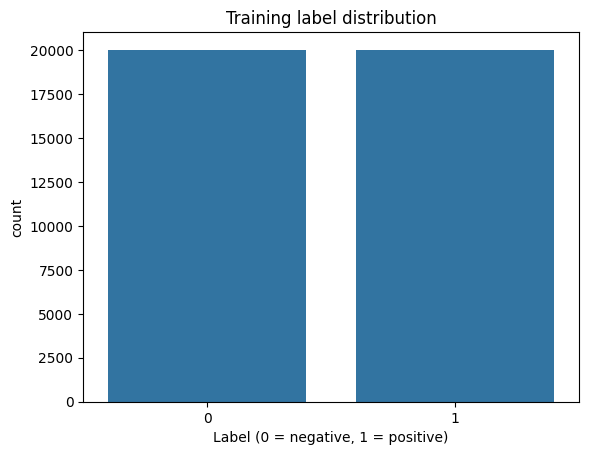

In [ ]:
sns.countplot(data=train, x="label")
plt.title("Training label distribution")
plt.xlabel("Label (0 = negative, 1 = positive)")
plt.show()

In [ ]:
for frame in (train, valid, test):
    frame["text_clean"] = frame["text"].map(clean_text)

model = Pipeline([
    ("tfidf", TfidfVectorizer(strip_accents="unicode", sublinear_tf=True,
                              ngram_range=(1, 2), min_df=2, max_df=0.95,
                              max_features=100_000)),
    ("classifier", LogisticRegression(C=2.0, max_iter=1000, n_jobs=-1)),
])
model.fit(train["text_clean"], train["label"])
print("Vocabulary size:", len(model.named_steps["tfidf"].vocabulary_))

Vocabulary size: 100000


Validation accuracy: 0.9112
Validation F1: 0.9125
              precision    recall  f1-score   support

    negative       0.92      0.90      0.91      2486
    positive       0.90      0.92      0.91      2514

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000



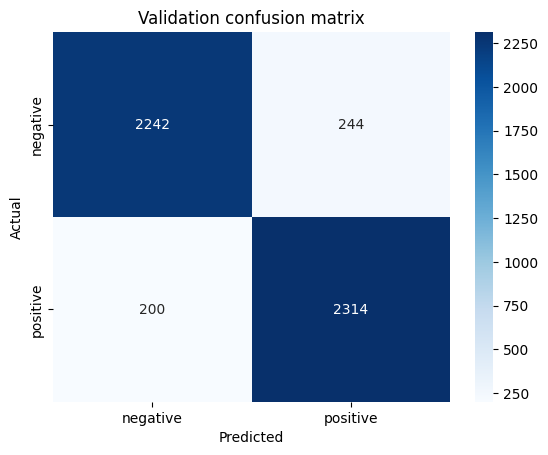

Test accuracy: 0.9102
Test F1: 0.9114
              precision    recall  f1-score   support

    negative       0.92      0.90      0.91      2495
    positive       0.90      0.92      0.91      2505

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000



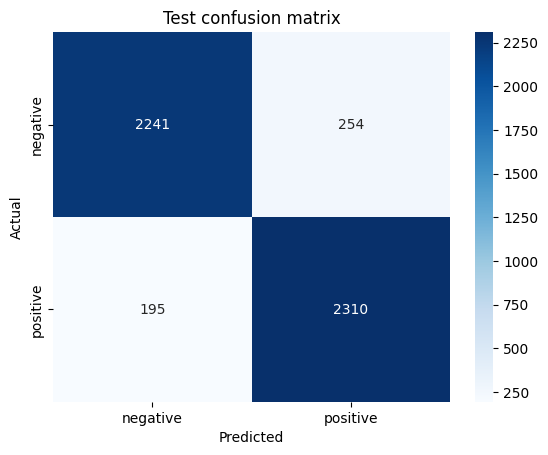

In [ ]:
def evaluate(frame, name):
    predictions = model.predict(frame["text_clean"])
    print(f"{name} accuracy: {accuracy_score(frame.label, predictions):.4f}")
    print(f"{name} F1: {f1_score(frame.label, predictions):.4f}")
    print(classification_report(frame.label, predictions, target_names=["negative", "positive"]))
    cm = confusion_matrix(frame.label, predictions)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["negative", "positive"],
                yticklabels=["negative", "positive"])
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"{name} confusion matrix"); plt.show()
    return predictions

valid_predictions = evaluate(valid, "Validation")
test_predictions = evaluate(test, "Test")


In [ ]:
examples = [
    "A thoughtful, moving film with excellent performances.",
    "The plot was dull and the acting was disappointing.",
]
for review, label in zip(examples, model.predict([clean_text(x) for x in examples])):
    print({"review": review, "predicted_label": int(label),
           "sentiment": "positive" if label == 1 else "negative"})


{'review': 'A thoughtful, moving film with excellent performances.', 'predicted_label': 1, 'sentiment': 'positive'}
{'review': 'The plot was dull and the acting was disappointing.', 'predicted_label': 0, 'sentiment': 'negative'}
